In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/scratch2/jsb92/20250523_HeLa_STORM/Cell3_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
image_files = H_F.file_search(image_folder, ".tif", "")

In [5]:
raw_data, first_frame, smoothed_frame, weights = IO.read_tiff_tophotoelectrons(
    image_files[0], frame=0, smoothing_function=smoothing_function
)

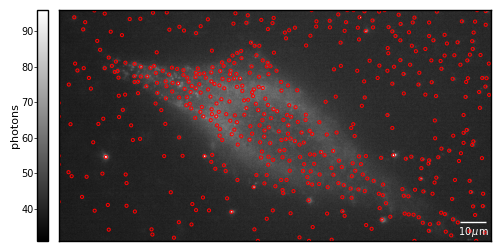

In [6]:
# play around with pfa to find a good parameter
fig, axs = SupRes_F.example_spots_singleframe(first_frame, pfa=1e-4)
plt.show()

In [7]:
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.647,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|█████████████████████████| 2800/2800 [00:34<00:00, 81.38task/s]


In [8]:
image_folder = "/scratch2/jsb92/20250523_HeLa_STORM/Cell4_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.647,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|█████████████████████████| 2800/2800 [00:32<00:00, 85.53task/s]


In [9]:
image_folder = "/scratch2/jsb92/20250523_HeLa_STORM/Cell2_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.647,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|█████████████████████████| 2800/2800 [00:30<00:00, 90.58task/s]


In [11]:
image_folder = "/scratch2/jsb92/20250523_HeLa_STORM/Cell1_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_2"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.647,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|████████████████████████| 2800/2800 [00:27<00:00, 100.62task/s]


In [14]:
folders = "/scratch2/jsb92/20250404_Ximea_AsynNRThX/data"
for image_folder in os.listdir(folders):
    SupRes_F.fit_imaging_data(
        os.path.join(folders, image_folder),
        smoothing_function,
        gain_map,
        offset_map,
        rqe,
        read_noise,
        pfa=1e-4,
        ROI_size=12,
        peak_wavelength=0.6,
        NA=1.49,
        pixel_size=0.069,
        image_type=".tif",
    )

LM fitting: 100%|████████████████████████| 2800/2800 [00:09<00:00, 304.10task/s]


In [15]:
image_folder = "/scratch2/jsb92/20250326_GattaQuantSlides/HiRes20R_40mW638_LP635_1"
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.638,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|████████████████████████| 2800/2800 [00:06<00:00, 445.26task/s]


In [16]:
image_folder = (
    "/scratch2/jsb92/20250326_GattaQuantSlides/HiRes205_10perc561_LP561_BP582-64_1"
)
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map,
    offset_map,
    rqe,
    read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.57,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

LM fitting: 100%|█████████████████████████| 2800/2800 [01:49<00:00, 25.65task/s]
